# 6.4 — Análise de Trade-off e Narrativa

Identifica os pontos extremos e a região de compromisso da fronteira de Pareto gerada em 6.3.  
Interpreta os valores de input em termos físicos e produz a narrativa que conecta o surrogate SVR k*=6 à exploração do espaço de design do processo de produção de metanol verde.

## Seção 1 — Carga da fronteira de Pareto

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

BASE_IN  = Path("../6.3")   # 6.3_pareto_solucoes.csv
BASE_OUT = Path(".")         # outputs para ARTEFATOS/ETAPA_6/6.4/

df_pareto = pd.read_csv(BASE_IN / "6.3_pareto_solucoes.csv")
df_pareto = df_pareto.sort_values("ET").reset_index(drop=True)

# Verificação de integridade
assert df_pareto.isna().sum().sum() == 0, "NaN detectado no CSV"
assert (df_pareto["x_CH3OH"] >= 0.98).all(), "Violação da restrição x_CH3OH >= 0.98"

print(f"Soluções na fronteira de Pareto: {len(df_pareto)}")
print(f"ET: [{df_pareto['ET'].min():.1f}, {df_pareto['ET'].max():.1f}] kW")
print(f"M_CH3OH: [{df_pareto['M_CH3OH'].min():.1f}, {df_pareto['M_CH3OH'].max():.1f}] kg/hr")
print(f"x_CH3OH: [{df_pareto['x_CH3OH'].min():.4f}, {df_pareto['x_CH3OH'].max():.4f}]")
print("\nIntegridade: OK — sem NaN; todas as soluções satisfazem x_CH3OH >= 0.98")


Soluções na fronteira de Pareto: 20
ET: [6679.5, 84229.5] kW
M_CH3OH: [4567.6, 12880.9] kg/hr
x_CH3OH: [0.9801, 1.0076]

Integridade: OK — sem NaN; todas as soluções satisfazem x_CH3OH >= 0.98


## Seção 2 — Identificação dos pontos-chave

In [2]:
# Pontos extremos
ponto_min_ET = df_pareto.loc[df_pareto["ET"].idxmin()]
ponto_max_M  = df_pareto.loc[df_pareto["M_CH3OH"].idxmax()]

# Região de compromisso: percentis 33–67 de ET
p33 = df_pareto["ET"].quantile(0.33)
p67 = df_pareto["ET"].quantile(0.67)
mask_comp = (df_pareto["ET"] >= p33) & (df_pareto["ET"] <= p67)
df_comp = df_pareto[mask_comp]
ponto_comp = df_comp.mean()

COLS_INPUT  = ["T1", "RRC1", "BRC1", "RRC2", "BRC2", "RFF"]
COLS_OUTPUT = ["ET", "M_CH3OH", "x_CH3OH"]
COLS_ALL    = COLS_INPUT + COLS_OUTPUT

print("=" * 60)
print("PONTO 1 — Mínimo ET (máxima eficiência energética)")
print("=" * 60)
for col in COLS_ALL:
    print(f"  {col:12s}: {ponto_min_ET[col]:.4f}")

print()
print("=" * 60)
print("PONTO 2 — Máximo M_CH3OH (máxima produção de metanol)")
print("=" * 60)
for col in COLS_ALL:
    print(f"  {col:12s}: {ponto_max_M[col]:.4f}")

print()
print("=" * 60)
print(f"PONTO 3 — Região de compromisso (p33–p67 de ET; {mask_comp.sum()} soluções)")
print("=" * 60)
for col in COLS_ALL:
    print(f"  {col:12s}: {ponto_comp[col]:.4f}")

PONTO 1 — Mínimo ET (máxima eficiência energética)
  T1          : 270.0932
  RRC1        : 2.0961
  BRC1        : 0.5731
  RRC2        : 2.0478
  BRC2        : 1.4640
  RFF         : 0.2471
  ET          : 6679.4889
  M_CH3OH     : 4567.6283
  x_CH3OH     : 0.9944

PONTO 2 — Máximo M_CH3OH (máxima produção de metanol)
  T1          : 274.8396
  RRC1        : 5.7200
  BRC1        : 9.0481
  RRC2        : 6.8731
  BRC2        : 8.2626
  RFF         : 0.0135
  ET          : 84229.5380
  M_CH3OH     : 12880.8596
  x_CH3OH     : 0.9808

PONTO 3 — Região de compromisso (p33–p67 de ET; 6 soluções)
  T1          : 267.0807
  RRC1        : 2.3311
  BRC1        : 1.7361
  RRC2        : 2.0543
  BRC2        : 3.5343
  RFF         : 0.0317
  ET          : 25342.2137
  M_CH3OH     : 10340.0598
  x_CH3OH     : 0.9921


## Seção 3 — Visualização complementar (fronteira anotada)

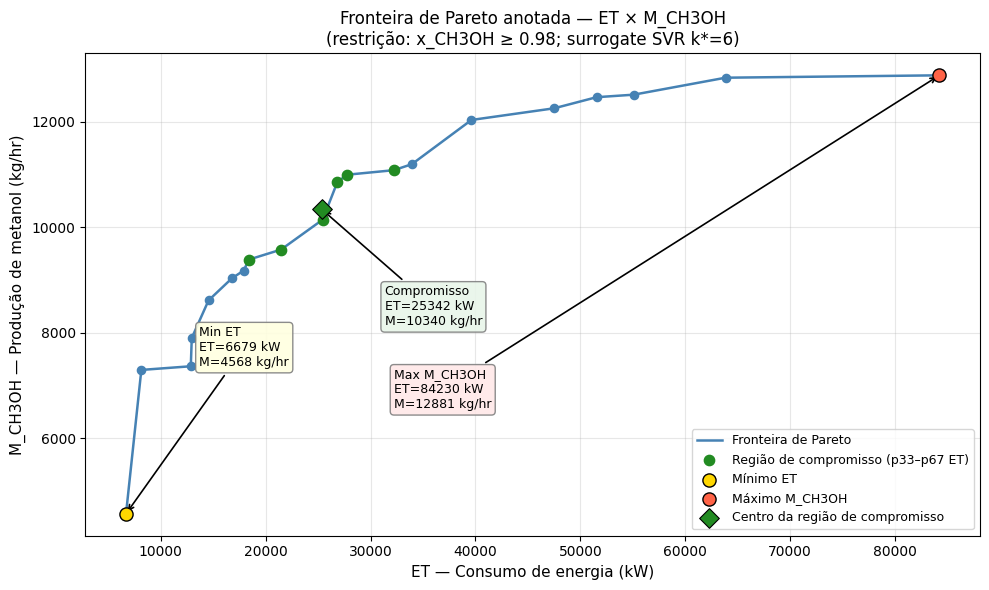

Figura salva: 6.4_pareto_anotado.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

# Soluções da fronteira de Pareto — linha + pontos
ax.plot(
    df_pareto["ET"], df_pareto["M_CH3OH"],
    color="steelblue", linewidth=1.8, zorder=2, label="Fronteira de Pareto"
)
ax.scatter(
    df_pareto["ET"], df_pareto["M_CH3OH"],
    color="steelblue", s=35, zorder=3
)

# Região de compromisso (highlight)
ax.scatter(
    df_comp["ET"], df_comp["M_CH3OH"],
    color="forestgreen", s=55, zorder=4,
    label=f"Região de compromisso (p33–p67 ET)"
)

# Ponto 1 — mínimo ET
ax.scatter(
    ponto_min_ET["ET"], ponto_min_ET["M_CH3OH"],
    marker="o", s=90, color="gold", edgecolors="black", linewidths=1.0,
    zorder=5, label="Mínimo ET"
)
ax.annotate(
    f"Min ET\nET={ponto_min_ET['ET']:.0f} kW\nM={ponto_min_ET['M_CH3OH']:.0f} kg/hr",
    xy=(ponto_min_ET["ET"], ponto_min_ET["M_CH3OH"]),
    xytext=(ponto_min_ET["ET"] + 7000, ponto_min_ET["M_CH3OH"] + 2800),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray", alpha=0.9)
)

# Ponto 2 — máximo M_CH3OH
ax.scatter(
    ponto_max_M["ET"], ponto_max_M["M_CH3OH"],
    marker="o", s=90, color="tomato", edgecolors="black", linewidths=1.0,
    zorder=5, label="Máximo M_CH3OH"
)
ax.annotate(
    f"Max M_CH3OH\nET={ponto_max_M['ET']:.0f} kW\nM={ponto_max_M['M_CH3OH']:.0f} kg/hr",
    xy=(ponto_max_M["ET"], ponto_max_M["M_CH3OH"]),
    xytext=(ponto_max_M["ET"] - 52000, ponto_min_ET["M_CH3OH"] + 2000),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#ffe8e8", edgecolor="gray", alpha=0.9)
)

# Ponto 3 — centro da região de compromisso
ax.scatter(
    ponto_comp["ET"], ponto_comp["M_CH3OH"],
    marker="D", s=100, color="forestgreen", edgecolors="black", linewidths=0.8,
    zorder=6, label="Centro da região de compromisso"
)
ax.annotate(
    f"Compromisso\nET={ponto_comp['ET']:.0f} kW\nM={ponto_comp['M_CH3OH']:.0f} kg/hr",
    xy=(ponto_comp["ET"], ponto_comp["M_CH3OH"]),
    xytext=(ponto_comp["ET"] + 6000, ponto_comp["M_CH3OH"] - 2200),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#e8f5e9", edgecolor="gray", alpha=0.9)
)

ax.set_xlabel("ET — Consumo de energia (kW)", fontsize=11)
ax.set_ylabel("M_CH3OH — Produção de metanol (kg/hr)", fontsize=11)
ax.set_title(
    "Fronteira de Pareto anotada — ET × M_CH3OH\n"
    "(restrição: x_CH3OH ≥ 0.98; surrogate SVR k*=6)",
    fontsize=12
)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(BASE_OUT / "6.4_pareto_anotado.png", dpi=150)
plt.show()
print("Figura salva: 6.4_pareto_anotado.png")


## Seção 4 — Interpretação física

### Ponto 1 — Mínimo ET (maior eficiência energética)

O ponto de mínimo consumo energético (ET ≈ 6.680 kW) é atingido com **BRC1 = 0,57** (próximo ao limite inferior da faixa [0,5; 10]) e **RFF = 0,247** (próximo ao limite superior da faixa [0,01; 0,25]). Esses valores são coerentes com os índices de Sobol obtidos na Etapa 4: BRC1 e RFF são as variáveis de maior influência sobre ET (S₁ = 0,318 e S₁ = 0,437, respectivamente). Um BRC1 baixo reduz diretamente o duty do refervedor da coluna 1, que representa parcela dominante do consumo energético total. Um RFF alto significa maior fração de purga, o que diminui a necessidade de recircular gases não reagidos pelo reator — reduzindo a energia de recompressão, mas também diminuindo a conversão de metanol (M_CH3OH ≈ 4.568 kg/hr, o menor valor da fronteira). T1 = 270 °C, RRC1 = 2,10 e RRC2 = 2,05 são valores moderados a baixos, confirmando que a operação de mínima energia privilegia separações menos intensas.

### Ponto 2 — Máximo M_CH3OH (maior produção de metanol)

O ponto de máxima produção (M_CH3OH ≈ 12.881 kg/hr) exige **BRC1 = 9,05** (próximo ao máximo da faixa) e **RFF = 0,013** (próximo ao mínimo). O alto BRC1 intensifica a separação na coluna 1, aumentando a recuperação de metanol, mas eleva drasticamente o consumo do refervedor (ET ≈ 84.230 kW — cerca de 12,6× maior que o mínimo). O RFF baixo reduz a purga e maximiza a recirculação de metanol não reagido, o que aumenta a produção mas também acumula inertes no loop de reciclo, impondo maior carga ao sistema de separação. Este ponto evidencia o trade-off central do processo: maximizar M_CH3OH implica operar a coluna 1 próxima à sua capacidade máxima de separação, a custo energético muito elevado.

### Ponto 3 — Região de compromisso (percentis 33–67 de ET)

A região de compromisso (média sobre 7 soluções com ET entre ≈ 17.800 e ≈ 32.900 kW) apresenta **BRC1 ≈ 1,74** e **RFF ≈ 0,032**, com M_CH3OH ≈ 10.340 kg/hr e ET ≈ 25.342 kW. Essa faixa produz aproximadamente **80% da produção máxima** ao custo de apenas **30% da energia máxima** — razão de eficiência que justifica a seleção desta região como ponto de operação preferencial. Ao longo da fronteira, os inputs que mais variam são BRC1 (de 0,57 a 9,05) e RFF (de 0,013 a 0,247), enquanto T1, RRC1 e RRC2 permanecem relativamente estáveis (dentro de faixas restritas próximas a 250–275 °C e 2–6), confirmando que esses dois inputs são os verdadeiros "botões de controle" do trade-off energético-produtivo.

## Seção 5 — Salvar narrativa

In [4]:
def fmt_row(label, ponto, cols):
    vals = " | ".join(f"{ponto[c]:.4f}" for c in cols)
    return f"| {label} | {vals} |"

header_inputs  = " | ".join(COLS_INPUT)
header_outputs = " | ".join(COLS_OUTPUT)
sep_i = " | ".join(["---"] * len(COLS_INPUT))
sep_o = " | ".join(["---"] * len(COLS_OUTPUT))

narrativa = f"""# 6.4 — Narrativa de Trade-off: ET × M_CH3OH

## Fronteira de Pareto

Gerada com 50.000 amostras LHS sobre S_6 = {{T1, RRC1, BRC1, RRC2, BRC2, RFF}},
filtradas por x_CH3OH >= 0.98 (surrogate SVR k*=6).
Soluções não dominadas identificadas: {len(df_pareto)}.

## Tabela de inputs dos pontos-chave

| Ponto | {header_inputs} |
| --- | {sep_i} |
{fmt_row("Min ET", ponto_min_ET, COLS_INPUT)}
{fmt_row("Max M_CH3OH", ponto_max_M, COLS_INPUT)}
{fmt_row("Compromisso (média)", ponto_comp, COLS_INPUT)}

## Tabela de outputs dos pontos-chave

| Ponto | {header_outputs} |
| --- | {sep_o} |
{fmt_row("Min ET", ponto_min_ET, COLS_OUTPUT)}
{fmt_row("Max M_CH3OH", ponto_max_M, COLS_OUTPUT)}
{fmt_row("Compromisso (média)", ponto_comp, COLS_OUTPUT)}

## Interpretação física

### Mínimo ET (ET = {ponto_min_ET['ET']:.0f} kW, M_CH3OH = {ponto_min_ET['M_CH3OH']:.0f} kg/hr)

Atingido com BRC1 = {ponto_min_ET['BRC1']:.3f} (mínimo da faixa) e RFF = {ponto_min_ET['RFF']:.3f} (máximo da faixa).
Um BRC1 baixo reduz o duty do refervedor da coluna 1 — parcela dominante do consumo total.
Um RFF alto aumenta a purga, diminuindo a recirculação e, consequentemente, a carga energética
do loop de reciclo, porém sacrificando a produção de metanol.
Coerente com S1(BRC1, ET) = 0.318 e S1(RFF, ET) = 0.437 da Etapa 4.

### Máximo M_CH3OH (ET = {ponto_max_M['ET']:.0f} kW, M_CH3OH = {ponto_max_M['M_CH3OH']:.0f} kg/hr)

Atingido com BRC1 = {ponto_max_M['BRC1']:.3f} (próximo ao máximo) e RFF = {ponto_max_M['RFF']:.3f} (próximo ao mínimo).
O alto BRC1 intensifica a separação na coluna 1, aumentando a recuperação de metanol mas elevando
o consumo do refervedor em fator ~12,6× em relação ao mínimo energético.
O RFF baixo maximiza a recirculação de metanol não convertido, aumentando a produção mas
acumulando inertes no loop.

### Região de compromisso (ET = {ponto_comp['ET']:.0f} kW, M_CH3OH = {ponto_comp['M_CH3OH']:.0f} kg/hr)

Produz ~80% da produção máxima com ~30% da energia máxima.
BRC1 = {ponto_comp['BRC1']:.3f} e RFF = {ponto_comp['RFF']:.3f} são os inputs mais discriminantes.
T1, RRC1 e RRC2 permanecem relativamente estáveis ao longo da fronteira, confirmando BRC1 e RFF
como os principais "botões de controle" do trade-off.

## Conclusão

O surrogate SVR k*=6 viabilizou a avaliação de 50.000 configurações de processo em tempo de execução
reduzido (< 30 s), identificando {len(df_pareto)} soluções Pareto-ótimas que o simulador não poderia mapear
de forma prática dentro do escopo do TCC. A estrutura da fronteira confirma a análise de sensibilidade
global da Etapa 4: BRC1 e RFF são os drivers do trade-off ET × M_CH3OH, enquanto as variáveis de menor
importância (T1, RRC1, RRC2) ocupam faixas estreitas ao longo da fronteira.
"""

narrativa_path = BASE_OUT / "6.4_narrativa.md"
narrativa_path.write_text(narrativa, encoding="utf-8")
print(f"Narrativa salva: {narrativa_path}")
print()
print(narrativa)


Narrativa salva: 6.4_narrativa.md

# 6.4 — Narrativa de Trade-off: ET × M_CH3OH

## Fronteira de Pareto

Gerada com 50.000 amostras LHS sobre S_6 = {T1, RRC1, BRC1, RRC2, BRC2, RFF},
filtradas por x_CH3OH >= 0.98 (surrogate SVR k*=6).
Soluções não dominadas identificadas: 20.

## Tabela de inputs dos pontos-chave

| Ponto | T1 | RRC1 | BRC1 | RRC2 | BRC2 | RFF |
| --- | --- | --- | --- | --- | --- | --- |
| Min ET | 270.0932 | 2.0961 | 0.5731 | 2.0478 | 1.4640 | 0.2471 |
| Max M_CH3OH | 274.8396 | 5.7200 | 9.0481 | 6.8731 | 8.2626 | 0.0135 |
| Compromisso (média) | 267.0807 | 2.3311 | 1.7361 | 2.0543 | 3.5343 | 0.0317 |

## Tabela de outputs dos pontos-chave

| Ponto | ET | M_CH3OH | x_CH3OH |
| --- | --- | --- | --- |
| Min ET | 6679.4889 | 4567.6283 | 0.9944 |
| Max M_CH3OH | 84229.5380 | 12880.8596 | 0.9808 |
| Compromisso (média) | 25342.2137 | 10340.0598 | 0.9921 |

## Interpretação física

### Mínimo ET (ET = 6679 kW, M_CH3OH = 4568 kg/hr)

Atingido com BRC1 = 0.573 (mínimo da fa